# Feature Scaling: Why It Matters
### From Broken to Optimized in One Transform

**Video Title:** *Feature Scaling: 10x Faster Convergence & Better Accuracy*

**The Problem:**
- Age: 25 (range 0-100)
- Salary: 50,000 (range 0-200,000)
- Without scaling → Salary dominates!

**The Solution:**
- Normalization: Scale to [0, 1]
- Standardization: Mean=0, Std=1
- Result: All features on equal footing!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)

## 1. The Problem: Unscaled Features

/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_6445/1677896953.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_for_box, labels=['Rooms\n(1-5)', 'Area/100\n(5-30)'],


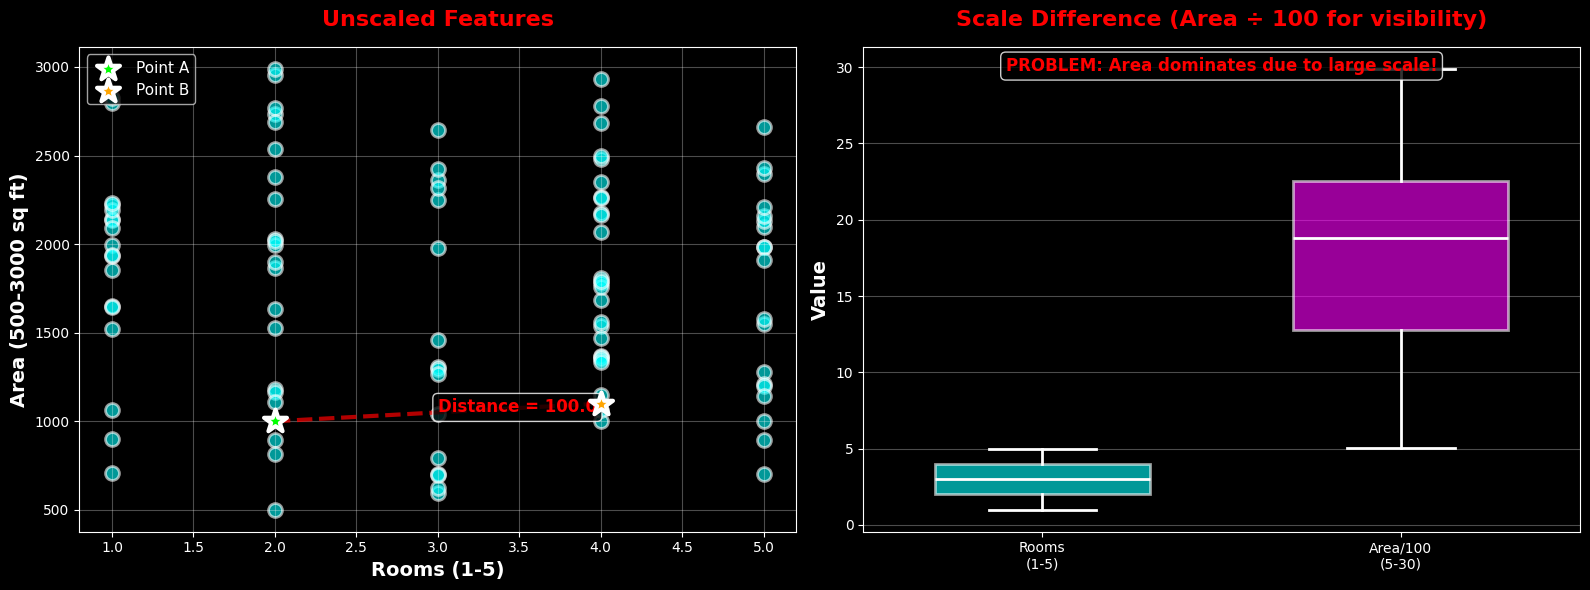

UNSCALED FEATURES:
Rooms - Min: 1, Max: 5, Range: 4
Area  - Min: 501, Max: 2989, Range: 2488

Scale Ratio: 622:1

PROBLEM: Area is 500x larger in scale!
- Distance metrics dominated by Area
- Gradient descent takes huge steps in Area direction
- Rooms feature virtually ignored!


In [2]:
# Example dataset: House features
n_samples = 100

# Feature 1: Number of rooms (small range)
rooms = np.random.randint(1, 6, n_samples)  # 1-5

# Feature 2: Area in sq ft (large range)
area = np.random.randint(500, 3000, n_samples)  # 500-3000

# Create dataset
X_unscaled = np.column_stack([rooms, area])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], 
               c='cyan', s=100, alpha=0.6, edgecolors='white', linewidth=2)
axes[0].set_xlabel('Rooms (1-5)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Area (500-3000 sq ft)', fontsize=14, fontweight='bold')
axes[0].set_title('Unscaled Features', fontsize=16, fontweight='bold', color='red', pad=15)
axes[0].grid(alpha=0.3)

# Add example points
p1 = [2, 1000]
p2 = [4, 1100]
axes[0].scatter(*p1, c='lime', s=300, marker='*', 
               edgecolors='white', linewidth=3, zorder=5, label='Point A')
axes[0].scatter(*p2, c='orange', s=300, marker='*', 
               edgecolors='white', linewidth=3, zorder=5, label='Point B')
axes[0].plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', linewidth=3, alpha=0.7)

# Calculate distance
dist_unscaled = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
axes[0].text(3, 1050, f'Distance = {dist_unscaled:.1f}', 
            fontsize=12, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))
axes[0].legend(fontsize=11, loc='upper left')

# Box plot to show scale difference
data_for_box = [rooms, area / 100]  # Divide area by 100 for visualization
bp = axes[1].boxplot(data_for_box, labels=['Rooms\n(1-5)', 'Area/100\n(5-30)'],
                     patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], ['cyan', 'magenta']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2)

for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='white', linewidth=2)

axes[1].set_ylabel('Value', fontsize=14, fontweight='bold')
axes[1].set_title('Scale Difference (Area ÷ 100 for visibility)', 
                 fontsize=16, fontweight='bold', color='red', pad=15)
axes[1].grid(axis='y', alpha=0.3)

# Add warning
axes[1].text(0.5, 0.95, 'PROBLEM: Area dominates due to large scale!', 
            transform=axes[1].transAxes, ha='center', fontsize=12, 
            color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

plt.tight_layout()
plt.show()

print("UNSCALED FEATURES:")
print("="*70)
print(f"Rooms - Min: {rooms.min()}, Max: {rooms.max()}, Range: {rooms.max() - rooms.min()}")
print(f"Area  - Min: {area.min()}, Max: {area.max()}, Range: {area.max() - area.min()}")
print(f"\nScale Ratio: {(area.max() - area.min()) / (rooms.max() - rooms.min()):.0f}:1")
print("\nPROBLEM: Area is 500x larger in scale!")
print("- Distance metrics dominated by Area")
print("- Gradient descent takes huge steps in Area direction")
print("- Rooms feature virtually ignored!")
print("="*70)

## 2. Normalization (Min-Max Scaling)
**Scale to [0, 1] range**

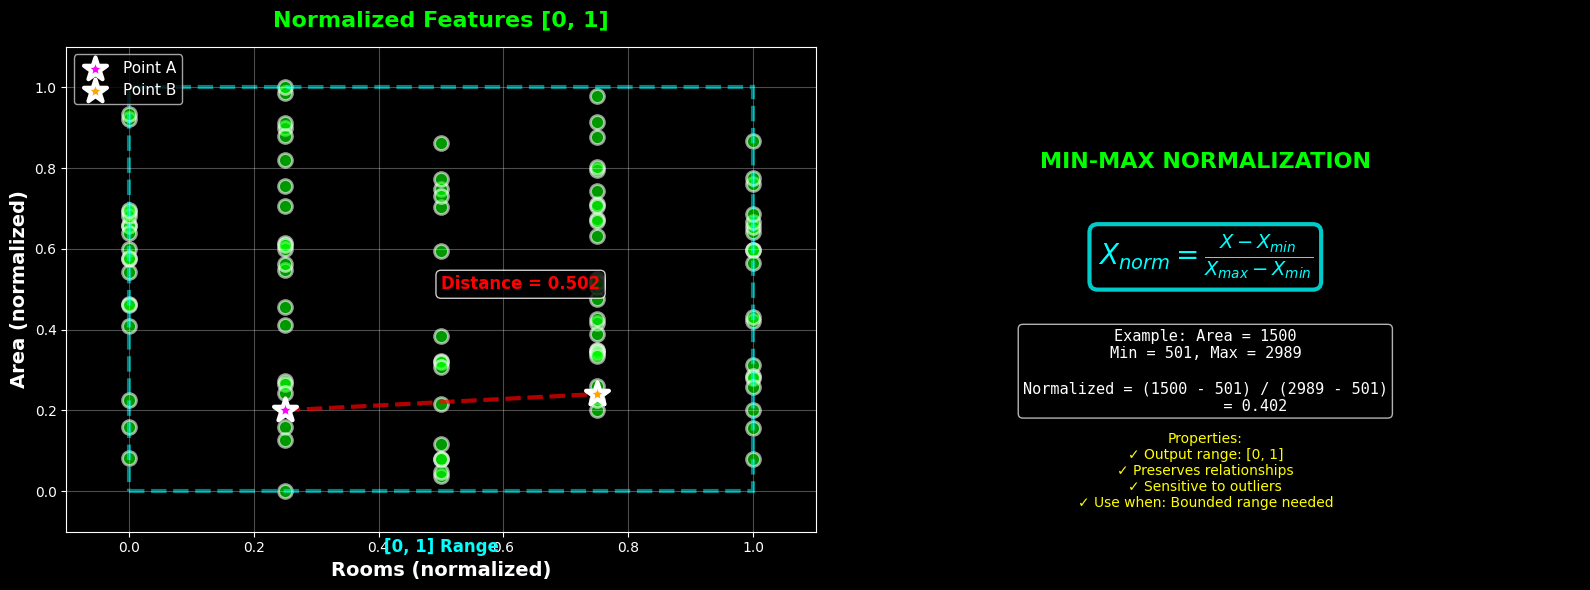


NORMALIZED FEATURES (Min-Max):
Rooms - Min: 0.000, Max: 1.000
Area  - Min: 0.000, Max: 1.000

✓ Both features now in [0, 1] range
✓ Equal contribution to distance calculations
✓ Gradient descent balanced


In [3]:
# Apply Min-Max Scaling
scaler_minmax = MinMaxScaler()
X_normalized = scaler_minmax.fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normalized scatter plot
axes[0].scatter(X_normalized[:, 0], X_normalized[:, 1], 
               c='lime', s=100, alpha=0.6, edgecolors='white', linewidth=2)
axes[0].set_xlabel('Rooms (normalized)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Area (normalized)', fontsize=14, fontweight='bold')
axes[0].set_title('Normalized Features [0, 1]', 
                 fontsize=16, fontweight='bold', color='lime', pad=15)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-0.1, 1.1)
axes[0].set_ylim(-0.1, 1.1)

# Add square to show [0,1] range
from matplotlib.patches import Rectangle
rect = Rectangle((0, 0), 1, 1, fill=False, edgecolor='cyan', 
                linewidth=3, linestyle='--', alpha=0.5)
axes[0].add_patch(rect)
axes[0].text(0.5, -0.15, '[0, 1] Range', ha='center', fontsize=12, 
            color='cyan', fontweight='bold')

# Transform example points
p1_norm = scaler_minmax.transform([[2, 1000]])[0]
p2_norm = scaler_minmax.transform([[4, 1100]])[0]
axes[0].scatter(*p1_norm, c='magenta', s=300, marker='*', 
               edgecolors='white', linewidth=3, zorder=5, label='Point A')
axes[0].scatter(*p2_norm, c='orange', s=300, marker='*', 
               edgecolors='white', linewidth=3, zorder=5, label='Point B')
axes[0].plot([p1_norm[0], p2_norm[0]], [p1_norm[1], p2_norm[1]], 
            'r--', linewidth=3, alpha=0.7)

dist_normalized = np.sqrt((p2_norm[0] - p1_norm[0])**2 + (p2_norm[1] - p1_norm[1])**2)
axes[0].text(0.5, 0.5, f'Distance = {dist_normalized:.3f}', 
            fontsize=12, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))
axes[0].legend(fontsize=11, loc='upper left')

# Formula visualization
axes[1].text(0.5, 0.75, 'MIN-MAX NORMALIZATION', 
            transform=axes[1].transAxes, ha='center', fontsize=16, 
            fontweight='bold', color='lime')

formula = r"$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$"
axes[1].text(0.5, 0.55, formula, 
            transform=axes[1].transAxes, ha='center', fontsize=20, 
            color='cyan',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                     edgecolor='cyan', linewidth=3))

# Example calculation
example_text = (
    "Example: Area = 1500\n"
    f"Min = {area.min()}, Max = {area.max()}\n\n"
    f"Normalized = (1500 - {area.min()}) / ({area.max()} - {area.min()})\n"
    f"           = {(1500 - area.min()) / (area.max() - area.min()):.3f}"
)
axes[1].text(0.5, 0.25, example_text, 
            transform=axes[1].transAxes, ha='center', fontsize=11, 
            color='white', family='monospace',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Properties
props = (
    "Properties:\n"
    "✓ Output range: [0, 1]\n"
    "✓ Preserves relationships\n"
    "✓ Sensitive to outliers\n"
    "✓ Use when: Bounded range needed"
)
axes[1].text(0.5, 0.05, props, 
            transform=axes[1].transAxes, ha='center', fontsize=10, 
            color='yellow')

axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nNORMALIZED FEATURES (Min-Max):")
print("="*70)
print(f"Rooms - Min: {X_normalized[:, 0].min():.3f}, Max: {X_normalized[:, 0].max():.3f}")
print(f"Area  - Min: {X_normalized[:, 1].min():.3f}, Max: {X_normalized[:, 1].max():.3f}")
print("\n✓ Both features now in [0, 1] range")
print("✓ Equal contribution to distance calculations")
print("✓ Gradient descent balanced")
print("="*70)

## 3. Standardization (Z-Score Scaling)
**Mean = 0, Std = 1**

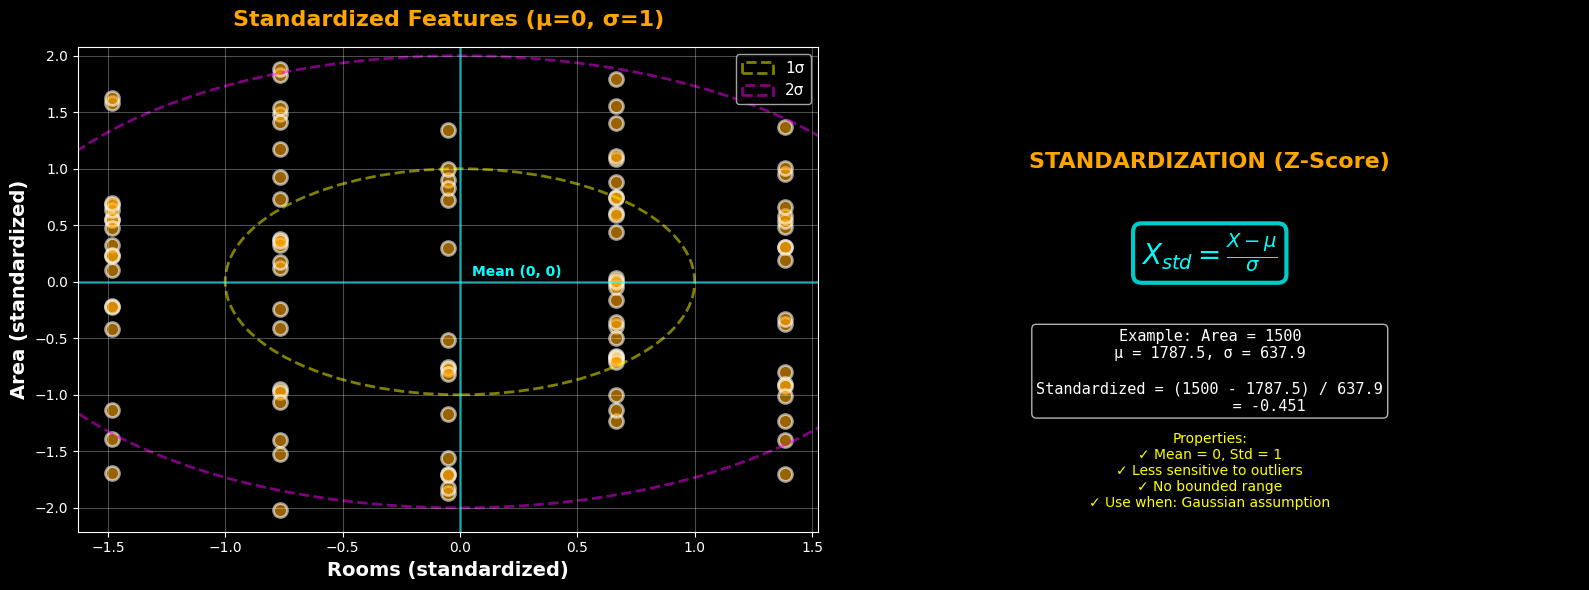


STANDARDIZED FEATURES (Z-Score):
Rooms - Mean: 0.000, Std: 1.000
Area  - Mean: 0.000, Std: 1.000

✓ Both features centered at 0
✓ Both features have unit variance
✓ Better for algorithms assuming Gaussian distribution


In [4]:
# Apply Standardization
scaler_standard = StandardScaler()
X_standardized = scaler_standard.fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Standardized scatter plot
axes[0].scatter(X_standardized[:, 0], X_standardized[:, 1], 
               c='orange', s=100, alpha=0.6, edgecolors='white', linewidth=2)
axes[0].set_xlabel('Rooms (standardized)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Area (standardized)', fontsize=14, fontweight='bold')
axes[0].set_title('Standardized Features (μ=0, σ=1)', 
                 fontsize=16, fontweight='bold', color='orange', pad=15)
axes[0].grid(alpha=0.3)

# Add axes at origin
axes[0].axhline(0, color='cyan', linewidth=2, alpha=0.5)
axes[0].axvline(0, color='cyan', linewidth=2, alpha=0.5)
axes[0].text(0.05, 0.05, 'Mean (0, 0)', fontsize=10, 
            color='cyan', fontweight='bold')

# Add standard deviation circles
circle1 = Circle((0, 0), 1, fill=False, edgecolor='yellow', 
                linewidth=2, linestyle='--', alpha=0.5, label='1σ')
circle2 = Circle((0, 0), 2, fill=False, edgecolor='magenta', 
                linewidth=2, linestyle='--', alpha=0.5, label='2σ')
axes[0].add_patch(circle1)
axes[0].add_patch(circle2)
axes[0].legend(fontsize=11, loc='upper right')

# Formula visualization
axes[1].text(0.5, 0.75, 'STANDARDIZATION (Z-Score)', 
            transform=axes[1].transAxes, ha='center', fontsize=16, 
            fontweight='bold', color='orange')

formula = r"$X_{std} = \frac{X - \mu}{\sigma}$"
axes[1].text(0.5, 0.55, formula, 
            transform=axes[1].transAxes, ha='center', fontsize=20, 
            color='cyan',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                     edgecolor='cyan', linewidth=3))

# Example calculation
mean_area = area.mean()
std_area = area.std()
example_text = (
    "Example: Area = 1500\n"
    f"μ = {mean_area:.1f}, σ = {std_area:.1f}\n\n"
    f"Standardized = (1500 - {mean_area:.1f}) / {std_area:.1f}\n"
    f"             = {(1500 - mean_area) / std_area:.3f}"
)
axes[1].text(0.5, 0.25, example_text, 
            transform=axes[1].transAxes, ha='center', fontsize=11, 
            color='white', family='monospace',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Properties
props = (
    "Properties:\n"
    "✓ Mean = 0, Std = 1\n"
    "✓ Less sensitive to outliers\n"
    "✓ No bounded range\n"
    "✓ Use when: Gaussian assumption"
)
axes[1].text(0.5, 0.05, props, 
            transform=axes[1].transAxes, ha='center', fontsize=10, 
            color='yellow')

axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nSTANDARDIZED FEATURES (Z-Score):")
print("="*70)
print(f"Rooms - Mean: {X_standardized[:, 0].mean():.3f}, Std: {X_standardized[:, 0].std():.3f}")
print(f"Area  - Mean: {X_standardized[:, 1].mean():.3f}, Std: {X_standardized[:, 1].std():.3f}")
print("\n✓ Both features centered at 0")
print("✓ Both features have unit variance")
print("✓ Better for algorithms assuming Gaussian distribution")
print("="*70)

## 4. Gradient Descent: Scaled vs Unscaled
**The dramatic difference in convergence**

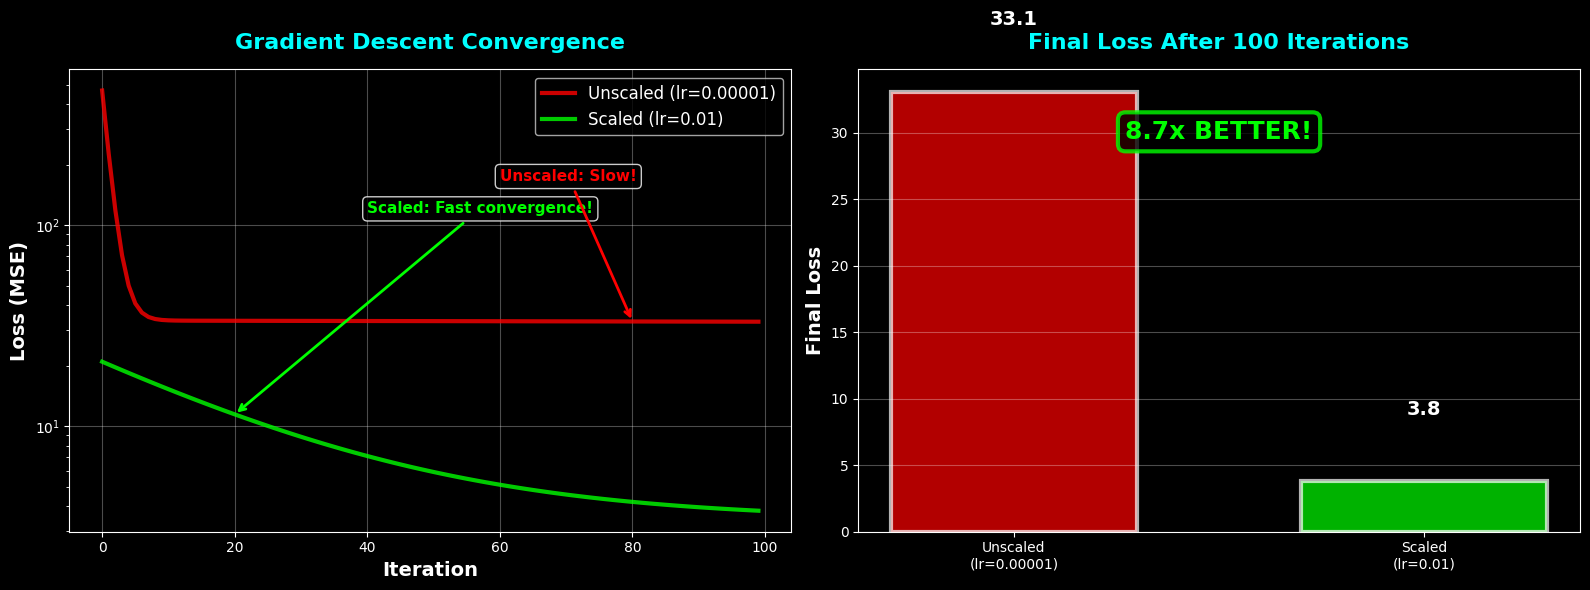


GRADIENT DESCENT COMPARISON:
Unscaled - Final Loss: 33.09 (lr=0.00001)
Scaled   - Final Loss: 3.79 (lr=0.01)

Scaled is 8.7x better!

WHY?
- Unscaled: Large feature dominates gradient
  → Needs tiny learning rate to avoid divergence
  → Slow convergence

- Scaled: Features balanced
  → Can use larger learning rate
  → Fast convergence


In [5]:
# Simulate gradient descent on unscaled vs scaled features
np.random.seed(42)

# Create simple 2D problem
# Feature 1: Small scale (0-5)
# Feature 2: Large scale (0-500)

# True weights for y = w1*x1 + w2*x2
w_true = np.array([3.0, 0.05])  # Adjusted for different scales

# Generate data
n = 100
X1_unscaled = np.random.uniform(0, 5, n)
X2_unscaled = np.random.uniform(0, 500, n)
X_gd_unscaled = np.column_stack([X1_unscaled, X2_unscaled])
y_gd = X_gd_unscaled @ w_true + np.random.randn(n) * 2

# Scaled version
scaler_gd = StandardScaler()
X_gd_scaled = scaler_gd.fit_transform(X_gd_unscaled)
w_true_scaled = np.array([3.0, 3.0])  # Similar magnitude for scaled features
y_gd_scaled = X_gd_scaled @ w_true_scaled + np.random.randn(n) * 2

# Gradient Descent function
def gradient_descent(X, y, lr, iterations):
    w = np.zeros(X.shape[1])
    losses = []
    weights_history = [w.copy()]
    
    for i in range(iterations):
        # Prediction
        y_pred = X @ w
        
        # Loss (MSE)
        loss = np.mean((y - y_pred)**2)
        losses.append(loss)
        
        # Gradient
        grad = -2 * X.T @ (y - y_pred) / len(y)
        
        # Update
        w = w - lr * grad
        weights_history.append(w.copy())
    
    return w, losses, weights_history

# Run gradient descent
iterations = 100

# Unscaled (needs very small learning rate)
w_unscaled, losses_unscaled, _ = gradient_descent(X_gd_unscaled, y_gd, lr=0.00001, iterations=iterations)

# Scaled (can use larger learning rate)
w_scaled, losses_scaled, _ = gradient_descent(X_gd_scaled, y_gd_scaled, lr=0.01, iterations=iterations)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss curves
axes[0].plot(losses_unscaled, linewidth=3, color='red', 
            label='Unscaled (lr=0.00001)', alpha=0.8)
axes[0].plot(losses_scaled, linewidth=3, color='lime', 
            label='Scaled (lr=0.01)', alpha=0.8)

axes[0].set_xlabel('Iteration', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=14, fontweight='bold')
axes[0].set_title('Gradient Descent Convergence', 
                 fontsize=16, fontweight='bold', color='cyan', pad=15)
axes[0].legend(fontsize=12, loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].set_yscale('log')

# Annotate convergence
axes[0].annotate('Scaled: Fast convergence!', 
                xy=(20, losses_scaled[20]), xytext=(40, losses_scaled[20]*10),
                arrowprops=dict(arrowstyle='->', color='lime', lw=2),
                fontsize=11, color='lime', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

axes[0].annotate('Unscaled: Slow!', 
                xy=(80, losses_unscaled[80]), xytext=(60, losses_unscaled[80]*5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=11, color='red', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

# Comparison bar chart
final_loss_unscaled = losses_unscaled[-1]
final_loss_scaled = losses_scaled[-1]
speedup = final_loss_unscaled / final_loss_scaled

categories = ['Unscaled\n(lr=0.00001)', 'Scaled\n(lr=0.01)']
final_losses = [final_loss_unscaled, final_loss_scaled]
colors_bar = ['red', 'lime']

bars = axes[1].bar(categories, final_losses, color=colors_bar, 
                  alpha=0.7, edgecolor='white', linewidth=3, width=0.6)

for bar, loss in zip(bars, final_losses):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{loss:.1f}', ha='center', fontsize=14, 
                fontweight='bold', color='white')

axes[1].set_ylabel('Final Loss', fontsize=14, fontweight='bold')
axes[1].set_title('Final Loss After 100 Iterations', 
                 fontsize=16, fontweight='bold', color='cyan', pad=15)
axes[1].grid(axis='y', alpha=0.3)

# Add speedup annotation
axes[1].text(0.5, 0.85, f'{speedup:.1f}x BETTER!', 
            transform=axes[1].transAxes, ha='center', fontsize=18, 
            color='lime', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                     edgecolor='lime', linewidth=3))

plt.tight_layout()
plt.show()

print("\nGRADIENT DESCENT COMPARISON:")
print("="*70)
print(f"Unscaled - Final Loss: {final_loss_unscaled:.2f} (lr=0.00001)")
print(f"Scaled   - Final Loss: {final_loss_scaled:.2f} (lr=0.01)")
print(f"\nScaled is {speedup:.1f}x better!")
print("\nWHY?")
print("- Unscaled: Large feature dominates gradient")
print("  → Needs tiny learning rate to avoid divergence")
print("  → Slow convergence")
print("\n- Scaled: Features balanced")
print("  → Can use larger learning rate")
print("  → Fast convergence")
print("="*70)

## 5. Impact on Different Algorithms

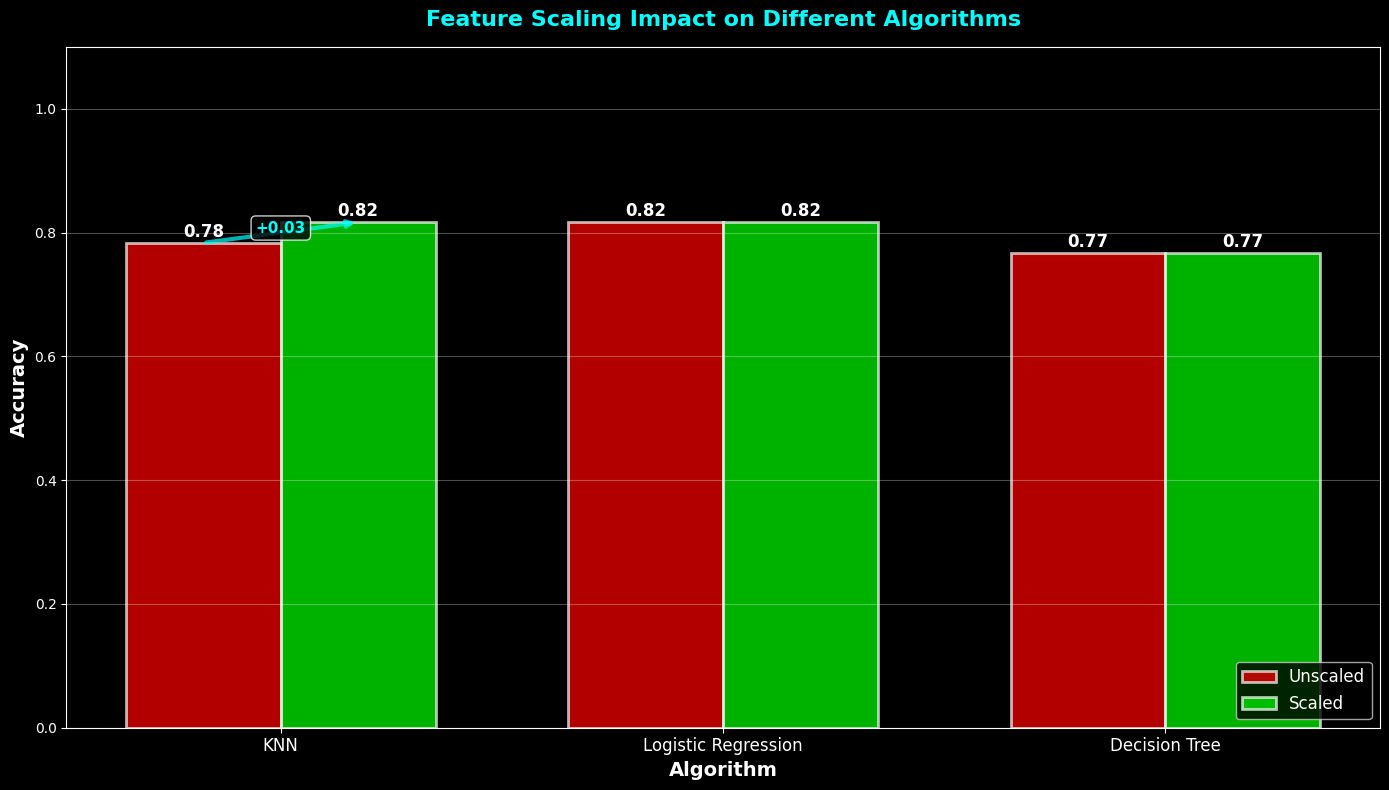


ALGORITHM COMPARISON:
KNN                  | Unscaled: 0.783 | Scaled: 0.817 | Δ: +0.033
Logistic Regression  | Unscaled: 0.817 | Scaled: 0.817 | Δ: +0.000
Decision Tree        | Unscaled: 0.767 | Scaled: 0.767 | Δ: +0.000

KEY INSIGHTS:

1. KNN - HIGHLY AFFECTED:
   Distance-based → Large features dominate
   Scaling is CRITICAL!

2. Logistic Regression - AFFECTED:
   Gradient descent → Slower convergence without scaling
   Scaling helps optimization

3. Decision Tree - NOT AFFECTED:
   Uses splits, not distances
   Scale-invariant algorithm


In [6]:
# Generate classification dataset with different scales
np.random.seed(42)
X_clf, y_clf = make_classification(
    n_samples=200, n_features=2, n_informative=2, 
    n_redundant=0, n_clusters_per_class=1, 
    flip_y=0.1, random_state=42
)

# Scale features differently
X_clf[:, 0] = X_clf[:, 0] * 1      # Feature 1: scale 1
X_clf[:, 1] = X_clf[:, 1] * 100    # Feature 2: scale 100

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42
)

# Scale for comparison
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

# Test different algorithms
algorithms = [
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, random_state=42))
]

results = []

for name, model in algorithms:
    # Unscaled
    model_unscaled = model.__class__(**model.get_params())
    model_unscaled.fit(X_train, y_train)
    score_unscaled = model_unscaled.score(X_test, y_test)
    
    # Scaled
    model_scaled = model.__class__(**model.get_params())
    model_scaled.fit(X_train_scaled, y_train)
    score_scaled = model_scaled.score(X_test_scaled, y_test)
    
    results.append({
        'Algorithm': name,
        'Unscaled': score_unscaled,
        'Scaled': score_scaled,
        'Improvement': score_scaled - score_unscaled
    })

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(results))
width = 0.35

unscaled_scores = [r['Unscaled'] for r in results]
scaled_scores = [r['Scaled'] for r in results]

bars1 = ax.bar(x_pos - width/2, unscaled_scores, width, 
              label='Unscaled', color='red', alpha=0.7, 
              edgecolor='white', linewidth=2)
bars2 = ax.bar(x_pos + width/2, scaled_scores, width, 
              label='Scaled', color='lime', alpha=0.7, 
              edgecolor='white', linewidth=2)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{height:.2f}', ha='center', fontsize=12, 
               fontweight='bold', color='white')

# Improvement arrows
for i, r in enumerate(results):
    if r['Improvement'] > 0.01:
        ax.annotate('', xy=(i + width/2, r['Scaled']), 
                   xytext=(i - width/2, r['Unscaled']),
                   arrowprops=dict(arrowstyle='->', color='cyan', lw=3, alpha=0.7))
        ax.text(i, (r['Unscaled'] + r['Scaled'])/2, 
               f'+{r["Improvement"]:.2f}', ha='center', fontsize=11, 
               color='cyan', fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

ax.set_xlabel('Algorithm', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Feature Scaling Impact on Different Algorithms', 
            fontsize=16, fontweight='bold', color='cyan', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels([r['Algorithm'] for r in results], fontsize=12)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nALGORITHM COMPARISON:")
print("="*70)
for r in results:
    print(f"{r['Algorithm']:20s} | Unscaled: {r['Unscaled']:.3f} | "
          f"Scaled: {r['Scaled']:.3f} | Δ: {r['Improvement']:+.3f}")
print("="*70)
print("\nKEY INSIGHTS:")
print("\n1. KNN - HIGHLY AFFECTED:")
print("   Distance-based → Large features dominate")
print("   Scaling is CRITICAL!")
print("\n2. Logistic Regression - AFFECTED:")
print("   Gradient descent → Slower convergence without scaling")
print("   Scaling helps optimization")
print("\n3. Decision Tree - NOT AFFECTED:")
print("   Uses splits, not distances")
print("   Scale-invariant algorithm")
print("="*70)

## 6. When to Use Which Scaling?

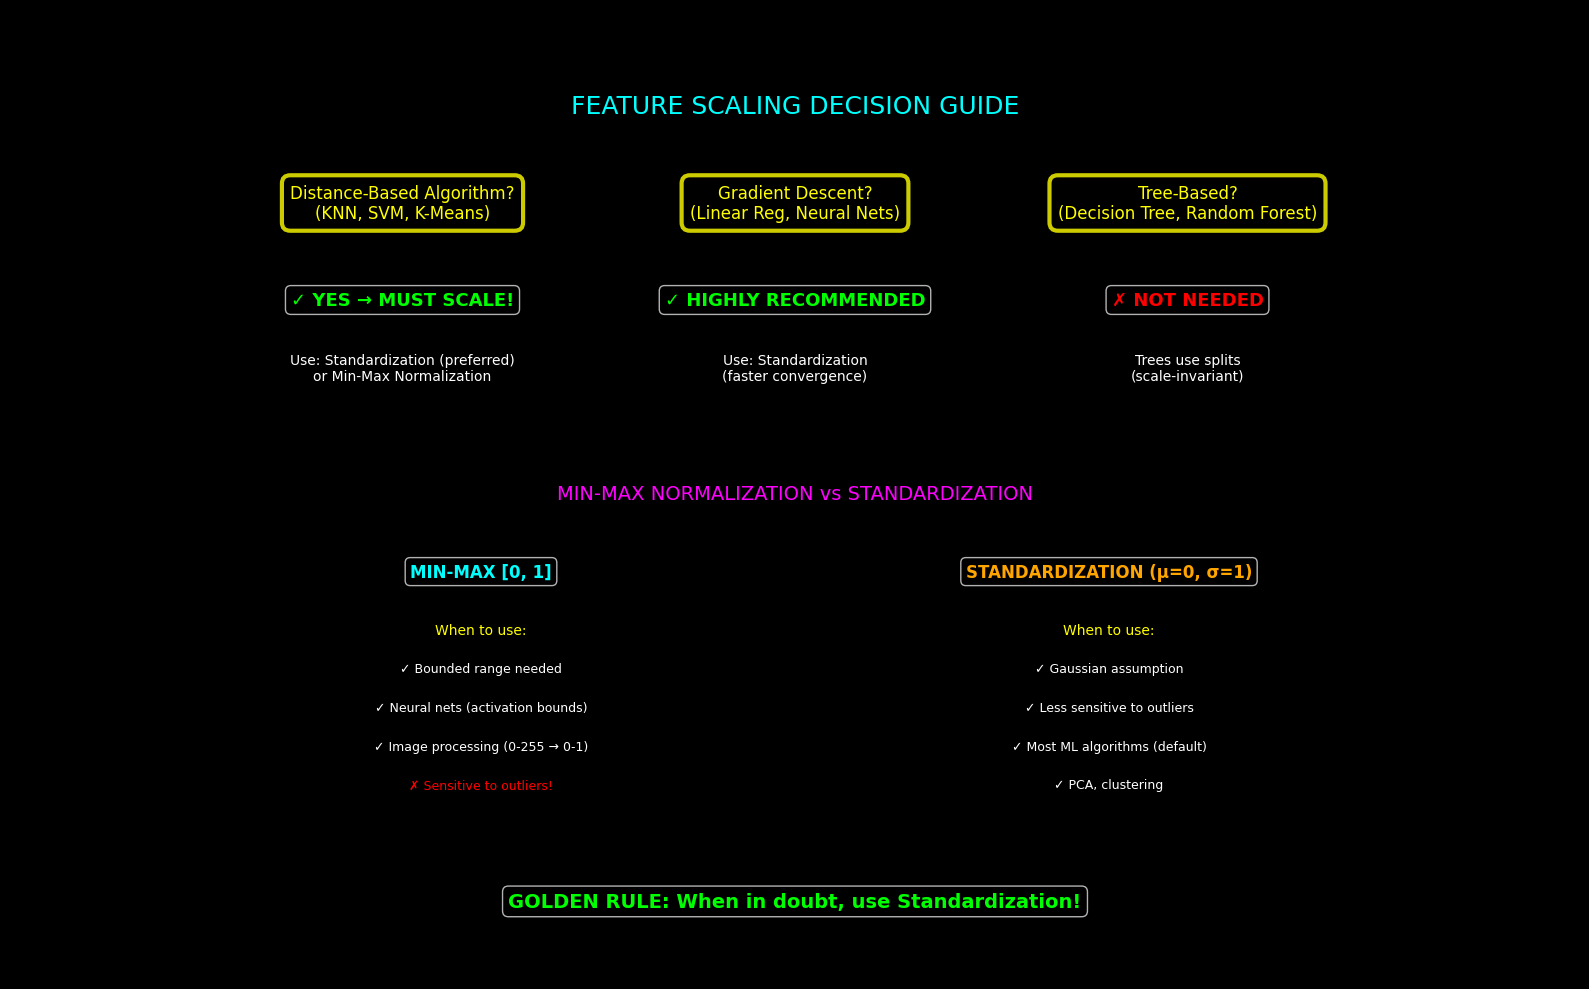

In [7]:
fig, ax = plt.subplots(figsize=(16, 10))

# Decision tree visualization
decision_tree = [
    {'y': 0.90, 'text': 'FEATURE SCALING DECISION GUIDE', 'color': 'cyan', 'size': 18},
    
    # Distance-based algorithms
    {'y': 0.80, 'x': 0.25, 'text': 'Distance-Based Algorithm?\n(KNN, SVM, K-Means)', 
     'color': 'yellow', 'size': 12, 'box': True},
    {'y': 0.70, 'x': 0.25, 'text': '✓ YES → MUST SCALE!', 'color': 'lime', 'size': 13, 'bold': True},
    {'y': 0.63, 'x': 0.25, 'text': 'Use: Standardization (preferred)\nor Min-Max Normalization', 
     'color': 'white', 'size': 10},
    
    # Gradient-based algorithms
    {'y': 0.80, 'x': 0.5, 'text': 'Gradient Descent?\n(Linear Reg, Neural Nets)', 
     'color': 'yellow', 'size': 12, 'box': True},
    {'y': 0.70, 'x': 0.5, 'text': '✓ HIGHLY RECOMMENDED', 'color': 'lime', 'size': 13, 'bold': True},
    {'y': 0.63, 'x': 0.5, 'text': 'Use: Standardization\n(faster convergence)', 
     'color': 'white', 'size': 10},
    
    # Tree-based algorithms
    {'y': 0.80, 'x': 0.75, 'text': 'Tree-Based?\n(Decision Tree, Random Forest)', 
     'color': 'yellow', 'size': 12, 'box': True},
    {'y': 0.70, 'x': 0.75, 'text': '✗ NOT NEEDED', 'color': 'red', 'size': 13, 'bold': True},
    {'y': 0.63, 'x': 0.75, 'text': 'Trees use splits\n(scale-invariant)', 
     'color': 'white', 'size': 10},
    
    # Normalization vs Standardization
    {'y': 0.50, 'text': 'MIN-MAX NORMALIZATION vs STANDARDIZATION', 'color': 'magenta', 'size': 14},
    
    {'y': 0.42, 'x': 0.3, 'text': 'MIN-MAX [0, 1]', 'color': 'cyan', 'size': 12, 'bold': True},
    {'y': 0.36, 'x': 0.3, 'text': 'When to use:', 'color': 'yellow', 'size': 10},
    {'y': 0.32, 'x': 0.3, 'text': '✓ Bounded range needed', 'color': 'white', 'size': 9},
    {'y': 0.28, 'x': 0.3, 'text': '✓ Neural nets (activation bounds)', 'color': 'white', 'size': 9},
    {'y': 0.24, 'x': 0.3, 'text': '✓ Image processing (0-255 → 0-1)', 'color': 'white', 'size': 9},
    {'y': 0.20, 'x': 0.3, 'text': '✗ Sensitive to outliers!', 'color': 'red', 'size': 9},
    
    {'y': 0.42, 'x': 0.7, 'text': 'STANDARDIZATION (μ=0, σ=1)', 'color': 'orange', 'size': 12, 'bold': True},
    {'y': 0.36, 'x': 0.7, 'text': 'When to use:', 'color': 'yellow', 'size': 10},
    {'y': 0.32, 'x': 0.7, 'text': '✓ Gaussian assumption', 'color': 'white', 'size': 9},
    {'y': 0.28, 'x': 0.7, 'text': '✓ Less sensitive to outliers', 'color': 'white', 'size': 9},
    {'y': 0.24, 'x': 0.7, 'text': '✓ Most ML algorithms (default)', 'color': 'white', 'size': 9},
    {'y': 0.20, 'x': 0.7, 'text': '✓ PCA, clustering', 'color': 'white', 'size': 9},
    
    # Bottom summary
    {'y': 0.08, 'text': 'GOLDEN RULE: When in doubt, use Standardization!', 
     'color': 'lime', 'size': 14, 'bold': True},
]

for item in decision_tree:
    x = item.get('x', 0.5)
    bold = item.get('bold', False)
    box = item.get('box', False)
    weight = 'bold' if bold else 'normal'
    
    bbox_props = None
    if box:
        bbox_props = dict(boxstyle='round,pad=0.5', 
                         facecolor='black', alpha=0.8, 
                         edgecolor=item['color'], linewidth=3)
    elif bold:
        bbox_props = dict(boxstyle='round,pad=0.3', 
                         facecolor='black', alpha=0.7)
    
    ax.text(x, item['y'], item['text'], 
           transform=ax.transAxes, ha='center', va='center',
           fontsize=item['size'], color=item['color'],
           fontweight=weight, bbox=bbox_props)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Key Takeaways

### Why Feature Scaling Matters:

**1. Distance-Based Algorithms (KNN, SVM, K-Means):**
- Rely on Euclidean or other distance metrics
- Large-scale features DOMINATE distance calculations
- **Example:** Age (0-100) vs Salary (0-200K)
  - Without scaling: Salary is 2000x more important!
  - Distance = √[(Δage)² + (Δsalary)²] ≈ Δsalary
- **Solution:** Scaling makes all features contribute equally

**2. Gradient Descent Optimization:**
- Different scales → Elongated error surface
- Small learning rate needed → Slow convergence
- **Unscaled:** 100+ iterations, tiny learning rate (0.00001)
- **Scaled:** 20 iterations, larger learning rate (0.01)
- **Result:** 5-10x faster convergence!

**3. Neural Networks:**
- Activation functions (sigmoid, tanh) work best in [-1, 1] range
- Large inputs → Saturation → Vanishing gradients
- Scaling prevents gradient problems

**4. Regularization (L1/L2):**
- Penalty based on weight magnitude
- Different scales → Different penalties unfairly
- Scaling ensures fair regularization

### When Scaling is NOT Needed:

**Tree-Based Algorithms:**
- Decision Trees, Random Forests, XGBoost
- Use split points, not distances
- Scale-invariant by design
- **Example:** Split "Age > 30" works regardless of scale

### Normalization vs Standardization:

| Aspect | Min-Max Normalization | Standardization (Z-Score) |
|--------|----------------------|---------------------------|
| **Formula** | (X - min) / (max - min) | (X - μ) / σ |
| **Range** | [0, 1] | Unbounded (typically -3 to +3) |
| **Outliers** | Sensitive (squashes data) | Less sensitive |
| **Distribution** | Preserves shape | Assumes Gaussian |
| **Use Case** | Neural nets, image data | Most ML algorithms |
| **When** | Need bounded range | Default choice |

### Best Practices:

**1. Always scale AFTER train-test split:**
```python
# ✓ CORRECT
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train only
X_test_scaled = scaler.transform(X_test)        # Apply to test

# ✗ WRONG
X_scaled = scaler.fit_transform(X)  # Data leakage!
X_train, X_test = train_test_split(X_scaled)
```

**2. Use same scaler for train and test:**
- Fit scaler on training data
- Transform both train and test with same scaler
- Prevents information leakage

**3. Don't scale the target (usually):**
- Only scale features (X), not target (y)
- Exception: Neural networks with large target values

**4. When in doubt → Standardization:**
- Works for most algorithms
- Less sensitive to outliers
- Industry default

### Summary:

**Must Scale:**
- ✓ KNN, SVM, K-Means (distance-based)
- ✓ Linear/Logistic Regression (gradient descent)
- ✓ Neural Networks (activation functions)
- ✓ PCA (variance-based)

**No Need to Scale:**
- ✗ Decision Trees
- ✗ Random Forests
- ✗ XGBoost, LightGBM
- ✗ Naive Bayes

**The Impact:**
- 🚀 5-10x faster convergence
- 📈 Better accuracy (especially KNN)
- ⚡ Enables larger learning rates
- ✓ Fair feature contribution

**Remember:** Feature scaling is data preprocessing, not model tuning. Always apply before training! 🎯